In [3]:
import sys
import json
import os


import wandb
import pandas as pd

from matplotlib import pyplot as plt

import numpy as np 


from tqdm import tqdm

from collections import OrderedDict

from datetime import datetime

from matplotlib.ticker import StrMethodFormatter

In [4]:
# import torch
# from torch import nn
# from torch.nn import functional as F
# from functools import partial

# from torch.utils.data import DataLoader
# from xaikd.utils import metrics
# from xaikd import models, datasets

# from contextlib import nullcontext

# from datetime import datetime

# from matplotlib import colormaps

# from torchvision import transforms



In [5]:
api = wandb.Api()

In [7]:
PROJECT = "p16i/xaikd-s51-distillation-some-vs-others"
EXPERIMENT_GROUP= "hyperopt"

In [66]:
def resolve_fitnet(teacher, verbose=False):
     
    if teacher in [
        "cifar100-resnet18-v1", 
        "imagenet-resnet18-tv",
        "imagenet-resnet50-tv",
        "imagenet-vgg16-tv",
    ]:
        actual_fitnet_policy = "fitnet-relu"
    elif teacher in [
        "imagenet-nfnetf0-dm",
        "imagenet-vitb-tv"
    ]:
        actual_fitnet_policy = "fitnet-noact"
    else:
        raise ValueError(f"not `fitnet` mapping for teacher={teacher}")

    if verbose:
        print(f"[teacher={teacher}] actual `fitnet` policy: {actual_fitnet_policy}")
    
    return actual_fitnet_policy
    
def read_data(
    teacher, student,
    dataset,
    policy,

    group_by,
    verbose=False,
    return_raw = False,
    training_size=1.0,
    experiment_group=EXPERIMENT_GROUP
):
    if policy == "fitnet":
        policy = resolve_fitnet(teacher, verbose=verbose)
    
    runs = api.runs(
        PROJECT,
        {
        "$and": [
            {"group": experiment_group},
            {"config.teacher": teacher},
            {"config.student": student},
            {"config.dataset": dataset},
            {"config.training_size": training_size},
            {"config.policy": policy},
        ]}
    )
    
    if verbose:
        print(f"we have {len(runs)} runs")
    
    rows = []
    
    count = 0
    
    for run in runs:
        seed = run.config["seed"]
        if not "arr_metrics"in run.summary:
            print(f">> bad run config (id={run.id}")

            count += 1
            return run
            continue

        rows.append(
            dict(
                val_auroc=run.summary["arr_metrics"]["val_auroc"][-1], 
                train_auroc=run.summary["arr_metrics"]["train_auroc"][:50][-1],
                # fixme: currently, there is a bug in the code where we use teacher_acc as teacher_auroc
                teacher_auroc=run.summary["teacher_auroc"],
                run_id=run.id,
                **run.config
            )
        )

    if count != 0:
        print(f"We have {count} bad run! abort!")
        raise
    
    df = pd.DataFrame(rows)
        
    assert df.shape[0] > 0
    df = df.groupby(by=group_by).agg(
        {
            "val_auroc": ["mean", "sem", "count"],
            "train_auroc": ["mean", "sem", "count"],

            "teacher_auroc": ["mean"],
        }
    ).reset_index()
    
    np.testing.assert_allclose(
        df["val_auroc"]["count"].values,
        3
    )
    
    if verbose:
        print(f"df.shape: {df.shape}")
    return df

read_data(
    teacher="cifar100-resnet18-v1",
    student="student-lenet",
    dataset = "cifar100-valsplit-people-vs-others",
    policy="vid",
    training_size=0.03125,
    verbose=True,
    group_by="lambda-layer",
)

we have 18 runs
df.shape: (6, 8)


lambda-layer val_auroc                 train_auroc                  \
                    mean       sem count        mean       sem count   
0        0.001  0.796933  0.007993     3    0.961771  0.006463     3   
1        0.010  0.799573  0.005749     3    0.962306  0.002090     3   
2        0.100  0.782986  0.010638     3    0.964565  0.003012     3   
3        1.000  0.785468  0.013531     3    0.966097  0.006604     3   
4       10.000  0.788309  0.004390     3    0.942344  0.004770     3   
5      100.000  0.787405  0.005707     3    0.924296  0.006102     3   

  teacher_auroc  
           mean  
0           1.0  
1           1.0  
2           1.0  
3           1.0  
4           1.0  
5           1.0

In [21]:
read_data(
    teacher="cifar100-resnet18-v1",
    student="student-mobilenetxs",
    dataset = "cifar100-valsplit-people-vs-others",
    policy="vid",
    training_size=0.125,
    verbose=True,
    group_by="lambda-layer",
)

we have 18 runs
df.shape: (6, 8)


lambda-layer val_auroc                 train_auroc                  \
                    mean       std count        mean       std count   
0        0.001  0.842220  0.025006     3    0.852468  0.051512     3   
1        0.010  0.829141  0.038446     3    0.859851  0.017146     3   
2        0.100  0.849968  0.017007     3    0.855328  0.034018     3   
3        1.000  0.759880  0.092433     3    0.875134  0.024067     3   
4       10.000  0.868402  0.008827     3    0.880702  0.015837     3   
5      100.000  0.847123  0.035657     3    0.866726  0.017749     3   

  teacher_auroc  
           mean  
0           1.0  
1           1.0  
2           1.0  
3           1.0  
4           1.0  
5           1.0

In [6]:

def alias(name):
    __dd = {
        "basis-identity:random--uncentered": "Random Subspace",
        "basis-identity:pca--uncentered": "RCM-PCA",
        "basis-identity:prca-sortabs--uncentered": "RCM-PRCA",
        "vid": "VID",
        "attention-transfer": "AT",
        "fitnet": "FitNet",
        "nothing": "KD Only"
    }
    return __dd.get(name, name)

def alias_teacher(name):
    __dd = {
        "cifar100-resnet18-v1": "ResNet18",
        "imagenet-resnet18-tv": "ResNet18",
        "imagenet-resnet50-tv": "ResNet50",
        "imagenet-vgg16-tv": "VGG16",
        "imagenet-nfnetf0-dm": "NFNet",
        "imagenet-vitb-tv": "ViT",
    }
    return __dd[name]

def alias_student(name):
    __dd = {
        "student-32-24-16-8": "S",
        "vitstudent-48": "S"
    }
    return __dd[name]

def alias_dataset(name):
    __dd = {
        "cifar100-valsplit-people": "CIFAR100 People",
        "imagenet-valsplit-butterfly": "ImageNet Butterfly",
    }
    return __dd[name]

def value_to_10expo(value):
    expo = np.log10(value)
    return "$10^{%d}$" % expo

# CIFAR100-ValSplit-People

## Curve

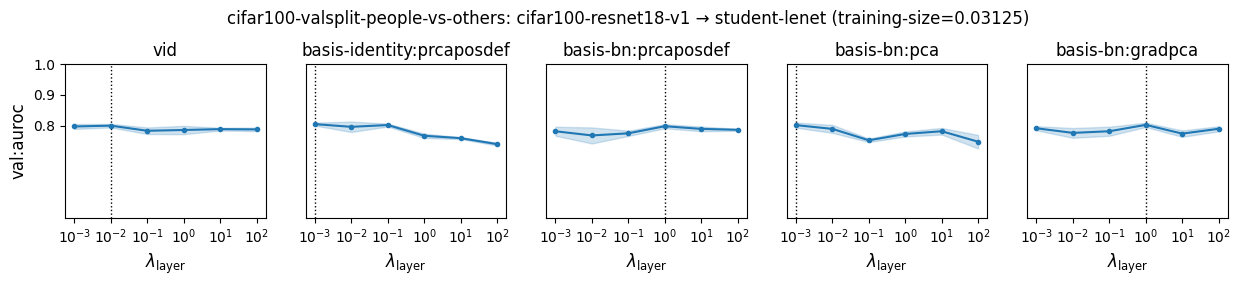

In [68]:
def viz(
    teacher, student,
    dataset,
    arr_policies = [
        "vid",
        "basis-identity:prcaposdef",
        "basis-bn:prcaposdef",
        "basis-bn:pca",
        "basis-bn:gradpca",
    ],
    training_size=1.0,
):

    metric_name = "auroc"
    
    ncols = len(arr_policies)
    nrows = 1
    num_policies = len(arr_policies)
    
    plt.figure(figsize=(3*ncols, 2*nrows))

    plt.suptitle(f"{dataset}: {teacher} → {student} (training-size={training_size})", y=1.15)


    for pix, policy in enumerate(arr_policies):
        plt.subplot(nrows, ncols,  pix+1)
        plt.title(policy, fontsize="large")
        df = read_data(
            teacher=teacher, student=student,
            dataset=dataset,
            policy=policy,
            
            group_by="lambda-layer",
            training_size=training_size,
        )
 
 
        ticks = df["lambda-layer"].values
        value = df[f"val_{metric_name}"]["mean"]
        stderr = df[f"val_{metric_name}"]["sem"]
        
        max_ix = np.argmax(value)
        plt.axvline(ticks[max_ix], ls=":", lw=1, color="k")
        
        plt.plot(
            ticks,
            value,
            marker=".",
        )
        plt.fill_between(
            ticks,
            value-stderr,
            value+stderr,
            color=plt.gca().lines[-1].get_color(),
            alpha=0.2
        )

        plt.ylim([0.5, 1.0])
        
        if pix == 0:
            plt.ylabel(f"val:{metric_name}", fontsize="large")
            plt.yticks([0.8, 0.9, 1.0])
        else:
            plt.yticks([])
        # plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.2f}')) # 2 decimal places
        
        plt.xscale("log")
        plt.xlabel("$\lambda_\mathrm{layer}$", fontsize="large")
        plt.xticks(ticks)
        

# viz(
#     teacher="cifar100-resnet18-v1",
#     student="student-mobilenetxs",

#     dataset = "cifar100-valsplit-people-vs-others",
#     training_size=1.0
# )

viz(
    teacher="cifar100-resnet18-v1",
    student="student-lenet",

    dataset = "cifar100-valsplit-people-vs-others",
    training_size=0.03125
)

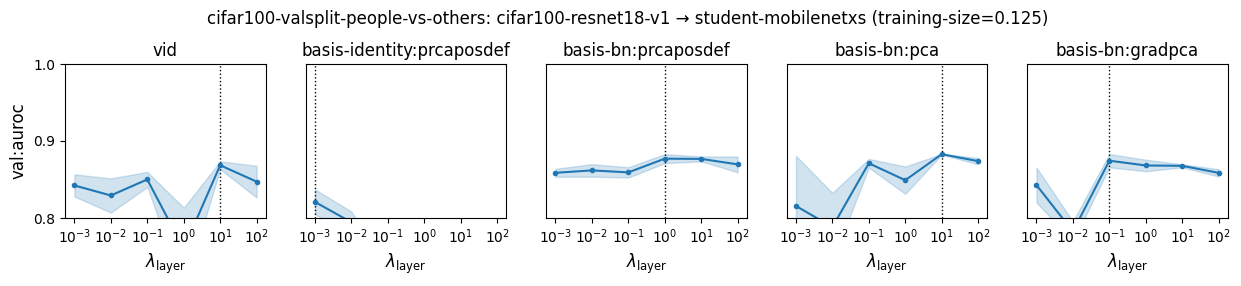

In [62]:
viz(
    teacher="cifar100-resnet18-v1",
    student="student-mobilenetxs",

    dataset = "cifar100-valsplit-people-vs-others",
    training_size=0.125
)

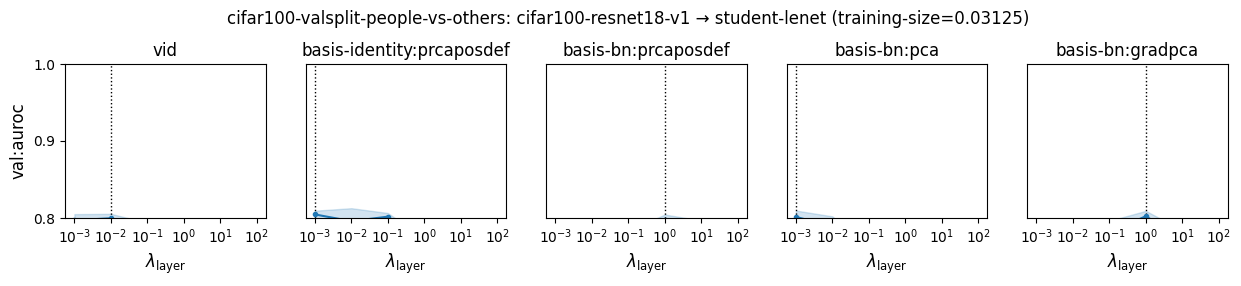

In [67]:
viz(
    teacher="cifar100-resnet18-v1",
    student="student-lenet",

    dataset = "cifar100-valsplit-people-vs-others",
    training_size=0.03125
)

## get_lambda_layer_default_values

In [58]:
def resolve_policy_actual_name(teacher, policy_name):
    if policy_name == "fitnet":
        if teacher in ["imagenet-vitb-tv", "imagenet-nfnetf0-dm"]:
            return "fitnet-noact"
        else:
            return "fitnet-relu"
    else:
        return policy_name
        
def get_lambda_layer_default_values(
    arr_teacher_student_pairs,
    dataset,
    arr_dataset_confs,
    arr_policies=[
        "vid",
        "basis-bn:pca",
        "basis-bn:gradpca",
        "basis-bn:prcaposdef",
    ],
):
  
    metric_name = "auroc"

    dict_best_results = dict()

    arr_teachers = list(map(lambda s: s[0], arr_teacher_student_pairs))

    for lambda_layer_config_slug, _ in arr_dataset_confs:
        dict_best_results[lambda_layer_config_slug] = dict(list(
            map(lambda t: (t, dict(nothing=0)), arr_teachers)
        ))



    for tix, (teacher, student) in enumerate(arr_teacher_student_pairs):        

        for lambda_layer_config_slug, training_size in arr_dataset_confs:


            for policy in arr_policies:
                
                policy_actual_name = resolve_policy_actual_name(teacher, policy)
                df = read_data(
                    teacher=teacher, 
                        student=student,
                    policy=policy,
                    dataset=dataset,
                    training_size=training_size,
                    group_by="lambda-layer",    
                )
                arr_val_accs = df[f"val_{metric_name}"]["mean"].values

                best_lambda_layer = df["lambda-layer"].values[np.argmax(arr_val_accs)]
                
                dict_best_results[lambda_layer_config_slug][teacher][policy_actual_name] = float(best_lambda_layer)


    print("##### config #####")

    print(json.dumps(
        dict_best_results,
        sort_keys=False, 
        indent=4
    ))

get_lambda_layer_default_values(
    arr_teacher_student_pairs=[
        ("cifar100-resnet18-v1", "student-mobilenetxs"),
    ],
    dataset="cifar100-valsplit-people-vs-others",
    arr_dataset_confs=[
        # (slug, training_size)
        ("cifar100-some-vs-others--clean", 1.0),
        ("cifar100-some-vs-others--small", 0.125),
    ],
)

##### config #####
{
    "cifar100-some-vs-others--clean": {
        "cifar100-resnet18-v1": {
            "nothing": 0,
            "vid": 1.0,
            "basis-bn:pca": 1.0,
            "basis-bn:gradpca": 0.001,
            "basis-bn:prcaposdef": 1.0
        }
    },
    "cifar100-some-vs-others--small": {
        "cifar100-resnet18-v1": {
            "nothing": 0,
            "vid": 10.0,
            "basis-bn:pca": 10.0,
            "basis-bn:gradpca": 0.1,
            "basis-bn:prcaposdef": 1.0
        }
    }
}


In [20]:
print(f"finished at {datetime.now()}")

finished at 2024-08-23 11:38:44.134176
